GRAFICO 7a: FUNCAO DE TRANSFERENCIA T(k)
omega_m = Omega_m h^2 = 0.1431
omega_b = Omega_b h^2 = 0.0224
a_eq = 1 / (1 + z_eq) = 2.940312e-04
k_eq (definicao do TCC) = 0.01041 Mpc^-1
k_eq (ajuste EH98)      = 0.01048 Mpc^-1
diferença relativa       = 0.7%
lambda_eq = 2*pi/k_eq   = 603.8 Mpc

Horizonte sonico no arrasto = 150.86 Mpc
Redshift do arrasto z_d     = 1020.8
Escala de Silk k_silk       = 0.0905 Mpc^-1

Grafico 7a gerado com sucesso.
Arquivos salvos:
  - grafico7a_transferencia_loglog.png
  - grafico7a_transferencia_loglog.pdf


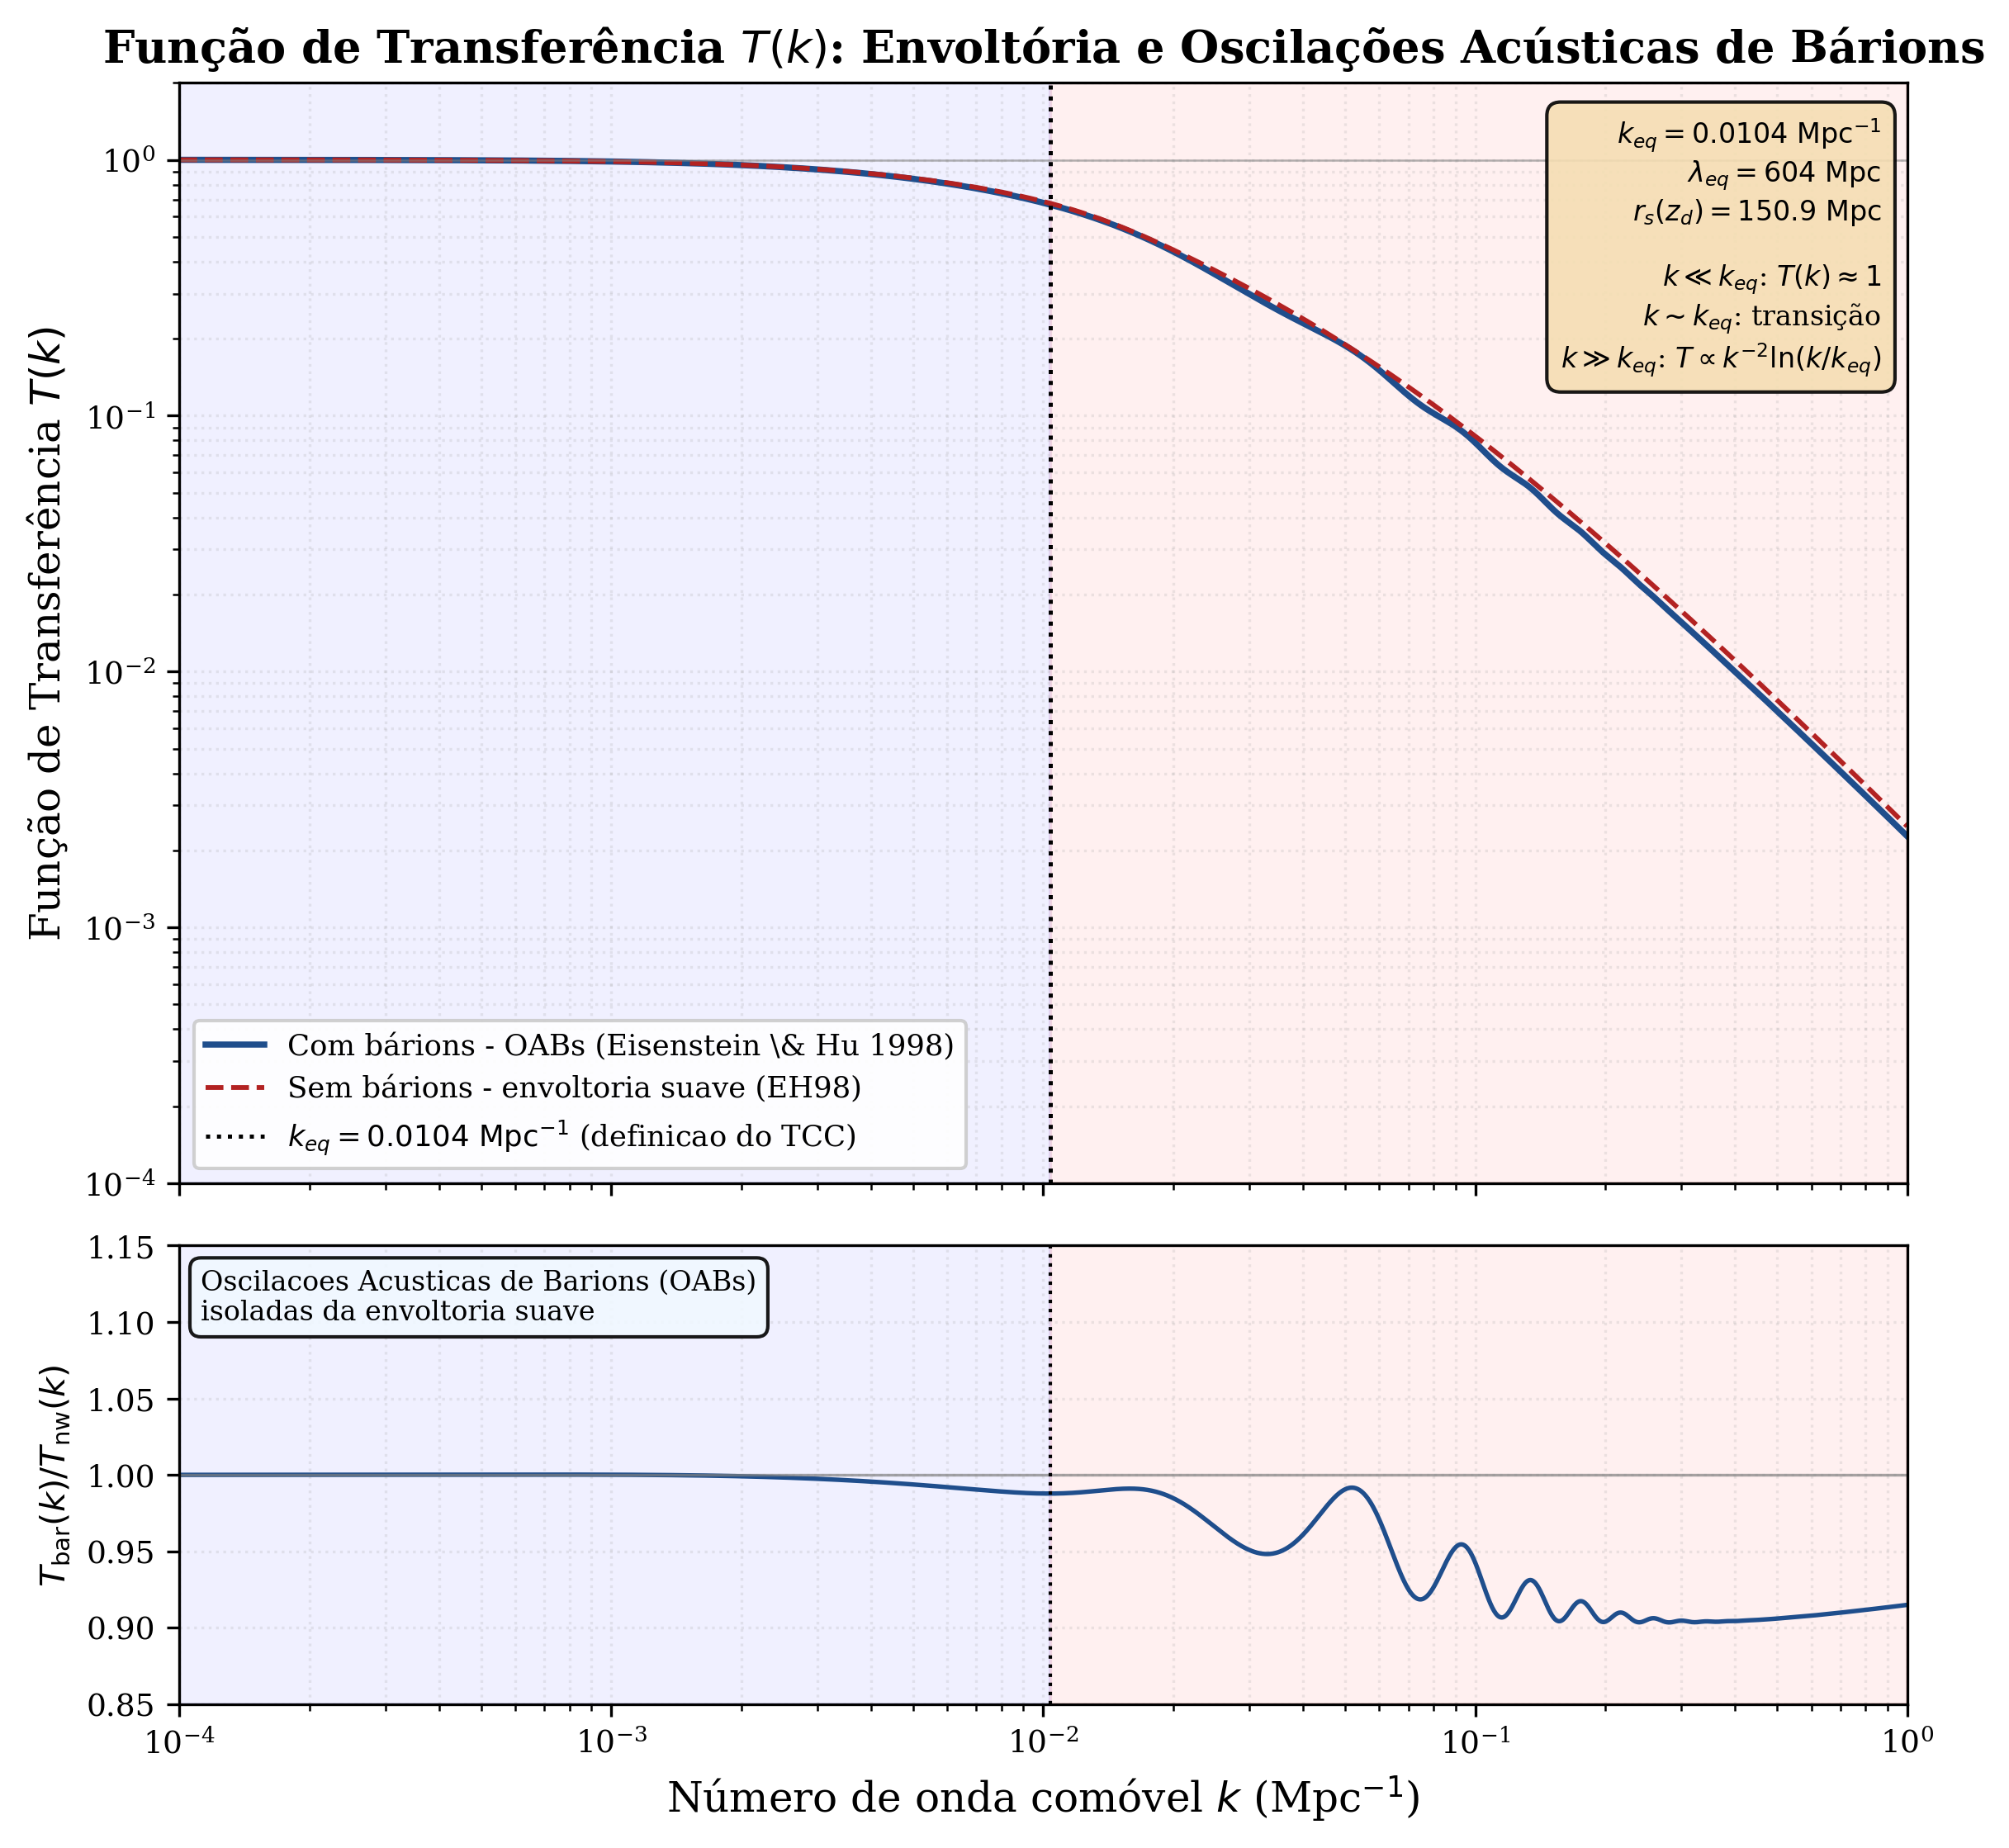

In [7]:
import numpy as np
import matplotlib.pyplot as plt


# =============================================================================
# CONFIGURACOES DE ESTILO
# =============================================================================

plt.style.use('default')

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'legend.fontsize': 9,
    'figure.titlesize': 14,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'lines.linewidth': 1.8,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'grid.linestyle': '--'
})


# =============================================================================
# PARAMETROS COSMOLOGICOS - Planck 2018
# =============================================================================

Omega_b_h2 = 0.0224
Omega_c_h2 = 0.120
Omega_m = 0.315

h = 0.674
z_eq = 3400
T_cmb = 2.7255


Omega_b = Omega_b_h2 / h**2
Omega_c = Omega_c_h2 / h**2

omega_m = Omega_m * h**2
omega_b = Omega_b_h2

c_luz = 299792.458
H0_Mpc = 100 * h / c_luz

Theta27 = T_cmb / 2.7


# =============================================================================
# ESCALA DE IGUALDADE MATeRIA-RADIACAO
#
# Definicao utilizada no TCC:
#
# k_eq = a_eq * H(a_eq)
#
# com
#
# a_eq = 1 / (1 + z_eq)
# =============================================================================

a_eq = 1.0 / (1.0 + z_eq)

k_eq = (
    H0_Mpc
    * np.sqrt(
        2.0
        * Omega_m
        * (1.0 + z_eq)
    )
)


# Formula de ajuste de Eisenstein & Hu (1998)
k_eq_EH98 = (
    7.46e-2
    * omega_m
    * Theta27**(-2)
)


print("=" * 68)
print("GRAFICO 7a: FUNCAO DE TRANSFERENCIA T(k)")
print("=" * 68)

print(
    f"omega_m = Omega_m h^2 = {omega_m:.4f}"
)

print(
    f"omega_b = Omega_b h^2 = {omega_b:.4f}"
)

print(
    f"a_eq = 1 / (1 + z_eq) = {a_eq:.6e}"
)

print(
    f"k_eq (definicao do TCC) = "
    f"{k_eq:.5f} Mpc^-1"
)

print(
    f"k_eq (ajuste EH98)      = "
    f"{k_eq_EH98:.5f} Mpc^-1"
)

relative_difference = (
    abs(k_eq - k_eq_EH98)
    / k_eq
    * 100
)

print(
    f"diferença relativa       = "
    f"{relative_difference:.1f}%"
)

lambda_eq = 2 * np.pi / k_eq

print(
    f"lambda_eq = 2*pi/k_eq   = "
    f"{lambda_eq:.1f} Mpc"
)


# =============================================================================
# QUANTIDADES AUXILIARES DE EISENSTEIN & HU (1998)
# =============================================================================

def eh98_auxiliary_quantities(
    omega_m,
    omega_b,
    Theta27
):
    """
    Calcula as quantidades auxiliares utilizadas
    na parametrizacao de Eisenstein & Hu (1998).
    """

    z_eq_eh = (
        2.5e4
        * omega_m
        * Theta27**(-4)
    )

    k_eq_eh = (
        7.46e-2
        * omega_m
        * Theta27**(-2)
    )


    b1 = (
        0.313
        * omega_m**(-0.419)
        * (
            1
            + 0.607 * omega_m**0.674
        )
    )

    b2 = (
        0.238
        * omega_m**0.223
    )


    z_d = (
        1291
        * omega_m**0.251
        / (
            1
            + 0.659 * omega_m**0.828
        )
        * (
            1
            + b1 * omega_b**b2
        )
    )


    R_eq = (
        31.5
        * omega_b
        * Theta27**(-4)
        * (z_eq_eh / 1e3)**(-1)
    )

    R_d = (
        31.5
        * omega_b
        * Theta27**(-4)
        * (z_d / 1e3)**(-1)
    )


    sound_horizon = (
        2.0
        / (3.0 * k_eq_eh)
        * np.sqrt(6.0 / R_eq)
        * np.log(
            (
                np.sqrt(1 + R_d)
                + np.sqrt(R_d + R_eq)
            )
            / (
                1
                + np.sqrt(R_eq)
            )
        )
    )


    k_silk = (
        1.6
        * omega_b**0.52
        * omega_m**0.73
        * (
            1
            + (10.4 * omega_m)**(-0.95)
        )
    )


    a1 = (
        (46.9 * omega_m)**0.670
        * (
            1
            + (32.1 * omega_m)**(-0.532)
        )
    )

    a2 = (
        (12.0 * omega_m)**0.424
        * (
            1
            + (45.0 * omega_m)**(-0.582)
        )
    )


    alpha_c = (
        a1**(-omega_b / omega_m)
        * a2**(-(omega_b / omega_m)**3)
    )


    b1c = (
        0.944
        / (
            1
            + (458 * omega_m)**(-0.708)
        )
    )

    b2c = (
        0.395 * omega_m
    )**(-0.0266)


    omega_c = omega_m - omega_b

    beta_c = (
        1.0
        / (
            1
            + b1c
            * (
                (omega_c / omega_m)**b2c
                - 1
            )
        )
    )


    y = (
        1
        + z_eq_eh
    ) / (1 + z_d)


    G_y = (
        y
        * (
            -6 * np.sqrt(1 + y)
            + (2 + 3 * y)
            * np.log(
                (np.sqrt(1 + y) + 1)
                / (np.sqrt(1 + y) - 1)
            )
        )
    )


    alpha_b = (
        2.07
        * k_eq_eh
        * sound_horizon
        * (1 + R_d)**(-0.75)
        * G_y
    )


    beta_node = (
        8.41
        * omega_m**0.435
    )


    beta_b = (
        0.5
        + omega_b / omega_m
        + (
            3
            - 2 * omega_b / omega_m
        )
        * np.sqrt(
            (17.2 * omega_m)**2
            + 1
        )
    )


    return {
        'z_eq': z_eq_eh,
        'k_eq': k_eq_eh,
        'z_d': z_d,
        'R_eq': R_eq,
        'R_d': R_d,
        's': sound_horizon,
        'k_silk': k_silk,
        'alpha_c': alpha_c,
        'beta_c': beta_c,
        'alpha_b': alpha_b,
        'beta_b': beta_b,
        'beta_node': beta_node
    }


# =============================================================================
# FUNCAO AUXILIAR T0
# =============================================================================

def T0_tilde(q, a_c, b_c):
    """
    Forma funcional T0 utilizada na parametrizacao
    de Eisenstein & Hu.
    """

    C = (
        14.2 / a_c
        + 386.0
        / (
            1
            + 69.9 * q**1.08
        )
    )

    L = np.log(
        np.e
        + 1.8 * b_c * q
    )

    return L / (
        L
        + C * q**2
    )


# =============================================================================
# FUNCAO DE TRANSFERENCIA COMPLETA
# =============================================================================

def transfer_function_EH98(
    k,
    params,
    omega_m,
    omega_b
):
    """
    Funcao de transferencia completa de Eisenstein & Hu,
    incluindo a componente de CDM e as oscilacoes acusticas
    bariônicas.
    """

    q = (
        k
        / (13.41 * params['k_eq'])
    )


    # -------------------------------------------------------------------------
    # Componente de materia escura fria
    # -------------------------------------------------------------------------

    f = (
        1.0
        / (
            1
            + (k * params['s'] / 5.4)**4
        )
    )


    T_c = (
        f
        * T0_tilde(
            q,
            1.0,
            1.0 / params['beta_c']
        )
        + (
            1 - f
        )
        * T0_tilde(
            q,
            params['alpha_c'],
            1.0 / params['beta_c']
        )
    )


    # -------------------------------------------------------------------------
    # Componente bariônica
    # -------------------------------------------------------------------------

    s_tilde = (
        params['s']
        / (
            1
            + (
                params['beta_node']
                / (k * params['s'])
            )**3
        )**(1.0 / 3.0)
    )


    # Funcao sinc na convencao do NumPy
    j0 = np.sinc(
        k * s_tilde / np.pi
    )


    T_b = (
        T0_tilde(
            q,
            1.0,
            1.0
        )
        / (
            1
            + (k * params['s'] / 5.2)**2
        )
        + (
            params['alpha_b']
            / (
                1
                + (
                    params['beta_b']
                    / (k * params['s'])
                )**3
            )
        )
        * np.exp(
            -(k / params['k_silk'])**1.4
        )
    ) * j0


    # -------------------------------------------------------------------------
    # Combinacao das componentes
    # -------------------------------------------------------------------------

    omega_c = omega_m - omega_b

    T = (
        (omega_b / omega_m) * T_b
        + (omega_c / omega_m) * T_c
    )

    return T


# =============================================================================
# FUNCAO DE TRANSFERENCIA SEM BARIOES
# =============================================================================

def transfer_function_zero_baryon(
    k,
    omega_m,
    omega_b,
    Theta27,
    sound_horizon
):
    """
    Envoltoria suave sem as oscilacoes acusticas bariônicas.
    """

    alpha_gamma = (
        1
        - 0.328
        * np.log(431 * omega_m)
        * (omega_b / omega_m)
        + 0.38
        * np.log(22.3 * omega_m)
        * (omega_b / omega_m)**2
    )


    gamma_eff = (
        omega_m
        * (
            alpha_gamma
            + (
                1 - alpha_gamma
            )
            / (
                1
                + (0.43 * k * sound_horizon)**4
            )
        )
    )


    q = (
        k * Theta27**2
        / gamma_eff
    )


    C0 = (
        14.2
        + 731.0
        / (
            1
            + 62.5 * q
        )
    )


    L0 = np.log(
        2 * np.e
        + 1.8 * q
    )


    return L0 / (
        L0
        + C0 * q**2
    )


# =============================================================================
# CALCULO DAS QUANTIDADES AUXILIARES
# =============================================================================

params = eh98_auxiliary_quantities(
    omega_m,
    omega_b,
    Theta27
)


print(
    f"\nHorizonte sonico no arrasto = "
    f"{params['s']:.2f} Mpc"
)

print(
    f"Redshift do arrasto z_d     = "
    f"{params['z_d']:.1f}"
)

print(
    f"Escala de Silk k_silk       = "
    f"{params['k_silk']:.4f} Mpc^-1"
)


# =============================================================================
# GRADE DE NUMERO DE ONDA
# =============================================================================

k_min = 1e-4
k_max = 1.0

k = np.logspace(
    np.log10(k_min),
    np.log10(k_max),
    2000
)


# Funcao de transferencia com barioes
T_full = transfer_function_EH98(
    k,
    params,
    omega_m,
    omega_b
)


# Funcao de transferencia sem oscilacoes
T_nw = transfer_function_zero_baryon(
    k,
    omega_m,
    omega_b,
    Theta27,
    params['s']
)


# Normalizacao para T(k) -> 1 em k -> 0
T_full = T_full / T_full[0]
T_nw = T_nw / T_nw[0]


# Razao entre as duas curvas
razao_wiggles = T_full / T_nw


# =============================================================================
# FIGURA
# =============================================================================

fig, (ax1, ax2) = plt.subplots(
    2,
    1,
    figsize=(9, 8.5),
    sharex=True,
    gridspec_kw={
        'height_ratios': [2.4, 1],
        'hspace': 0.08
    }
)


# =============================================================================
# PAINEL SUPERIOR
# =============================================================================

ax1.plot(
    k,
    T_full,
    color='#1f4e8c',
    linewidth=1.8,
    label=(
        r'Com bárions - OABs '
        r'(Eisenstein \& Hu 1998)'
    )
)


ax1.plot(
    k,
    T_nw,
    color='#b22222',
    linewidth=1.4,
    linestyle='--',
    label=(
        r'Sem bárions - envoltoria suave '
        r'(EH98)'
    )
)


# Linha vertical em k_eq
ax1.axvline(
    k_eq,
    color='black',
    linestyle=':',
    linewidth=1.2,
    label=(
        rf'$k_{{eq}} = {k_eq:.4f}\ '
        rf'\mathrm{{Mpc}}^{{-1}}$'
        r' (definicao do TCC)'
    )
)


# Linha de referencia T = 1
ax1.axhline(
    1.0,
    color='gray',
    linewidth=0.6,
    alpha=0.6
)


# Regioes antes e depois da igualdade
ax1.axvspan(
    k_min,
    k_eq,
    color='blue',
    alpha=0.06
)

ax1.axvspan(
    k_eq,
    k_max,
    color='red',
    alpha=0.06
)


# =============================================================================
# ESCALAS DO PAINEL SUPERIOR
# =============================================================================

ax1.set_xscale('log')
ax1.set_yscale('log')

ax1.set_xlim(
    k_min,
    k_max
)

ax1.set_ylim(
    1e-4,
    2
)


ax1.set_ylabel(
    r'Função de Transferência $T(k)$'
)


ax1.set_title(
    r'Função de Transferência $T(k)$: '
    r'Envoltória e Oscilações Acústicas de Bárions',
    fontweight='bold'
)


ax1.legend(
    loc='lower left',
    fontsize=8.5,
    framealpha=0.92
)


# =============================================================================
# INFORMACOES DO PAINEL SUPERIOR
# =============================================================================

info_text = (
    rf'$k_{{eq}} = {k_eq:.4f}\ '
    rf'\mathrm{{Mpc}}^{{-1}}$'
    '\n'
    rf'$\lambda_{{eq}} = {lambda_eq:.0f}\ \mathrm{{Mpc}}$'
    '\n'
    rf'$r_s(z_d) = {params["s"]:.1f}\ \mathrm{{Mpc}}$'
    '\n\n'
    r'$k \ll k_{eq}$: $T(k)\approx 1$'
    '\n'
    r'$k \sim k_{eq}$: transição'
    '\n'
    r'$k \gg k_{eq}$: '
    r'$T \propto k^{-2}\ln(k/k_{eq})$'
)


ax1.text(
    0.985,
    0.97,
    info_text,
    transform=ax1.transAxes,
    horizontalalignment='right',
    verticalalignment='top',
    fontsize=8,
    bbox=dict(
        boxstyle='round',
        facecolor='wheat',
        alpha=0.9,
        pad=0.5
    )
)


# =============================================================================
# PAINEL INFERIOR - RAZAO DAS DUAS CURVAS
# =============================================================================

ax2.plot(
    k,
    razao_wiggles,
    color='#1f4e8c',
    linewidth=1.3
)


ax2.axhline(
    1.0,
    color='gray',
    linewidth=0.8,
    linestyle='-',
    alpha=0.7
)


ax2.axvline(
    k_eq,
    color='black',
    linestyle=':',
    linewidth=1.0
)


ax2.axvspan(
    k_min,
    k_eq,
    color='blue',
    alpha=0.06
)

ax2.axvspan(
    k_eq,
    k_max,
    color='red',
    alpha=0.06
)


ax2.set_xscale('log')


ax2.set_xlim(
    k_min,
    k_max
)

ax2.set_ylim(
    0.85,
    1.15
)


ax2.set_xlabel(
    r'Número de onda comóvel $k$ (Mpc$^{-1}$)'
)

ax2.set_ylabel(
    r'$T_{\rm bar}(k)/T_{\rm nw}(k)$',
    fontsize=10
)


ax2.text(
    0.0125,
    0.825,
    'Oscilacoes Acusticas de Barions (OABs)\n'
    'isoladas da envoltoria suave',
    transform=ax2.transAxes,
    fontsize=8,
    verticalalignment='bottom',
    bbox=dict(
        boxstyle='round',
        facecolor='aliceblue',
        alpha=0.9,
        pad=0.4
    )
)


# =============================================================================
# GRADE E FORMATACAO FINAL
# =============================================================================

for axis in (ax1, ax2):

    axis.grid(
        True,
        which='both',
        alpha=0.25,
        linestyle=':'
    )

    axis.tick_params(
        labelsize=9
    )


# =============================================================================
# SALVAMENTO
# =============================================================================

# plt.tight_layout()


plt.savefig(
    'grafico7a_transferencia_loglog.png',
    dpi=300,
    bbox_inches='tight'
)

plt.savefig(
    'grafico7a_transferencia_loglog.pdf',
    dpi=300,
    bbox_inches='tight'
)


print("\nGrafico 7a gerado com sucesso.")
print("Arquivos salvos:")
print("  - grafico7a_transferencia_loglog.png")
print("  - grafico7a_transferencia_loglog.pdf")

print("=" * 68)


plt.show()